# Trajectory with STREAM2
 Stream2 trajectory and extract macrostates

Change the parameters here : 

In [48]:
# === PARAMETERS ===
input_file = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Matrix/p2_test.h5ad"
patient = "P2"
output_directory = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots"
reduction='X_umap' # Reduction on which trajectory learning is based (X_umap, X_pca, X_tsne)
nb_node= 50 # Number of nodes on the trajectory graph
nb_cluster= 80 # Number of cluster on the trajectory graph -> ramification

In [49]:
#!pip uninstall stream2 -y
#!pip install git+https://github.com/pinellolab/STREAM2.git
# Restart the kernel
import stream2 as st2
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
#!pip3 install leidenalg

In [50]:
adata = sc.read(input_file)

/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/anndata/_io/h5ad.py:266: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{


In [51]:
print(adata.obs["timepoint"].head())

D1_AAACCCAAGTCCCGAC-1    D1
D1_AAACCCACATAGCACT-1    D1
D1_AAACCCACATGGCCCA-1    D1
D1_AAACCCAGTCTTTCTA-1    D1
D1_AAACCCAGTTCTAAGC-1    D1
Name: timepoint, dtype: object


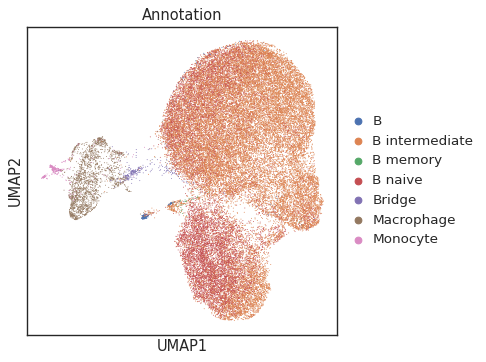

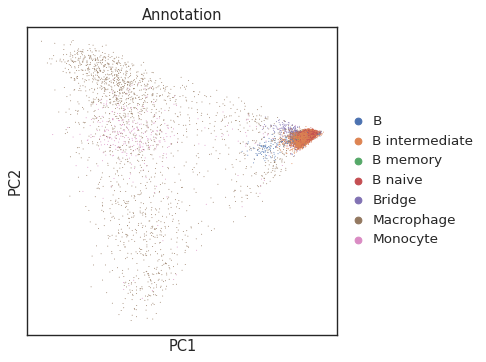

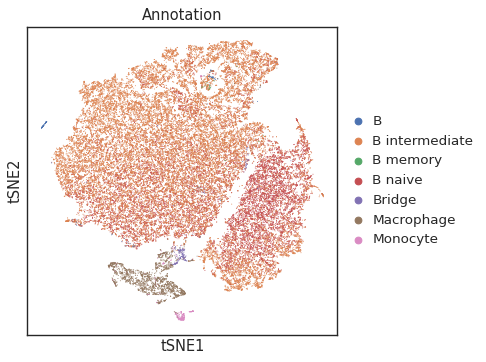

In [52]:
sc.pl.umap(adata,color=['Annotation'])
sc.pl.pca(adata,color=['Annotation'])
sc.pl.tsne(adata,color=['Annotation'])

/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/stream2/plotting/_plot.py:940: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if ann in adata.obs_keys():


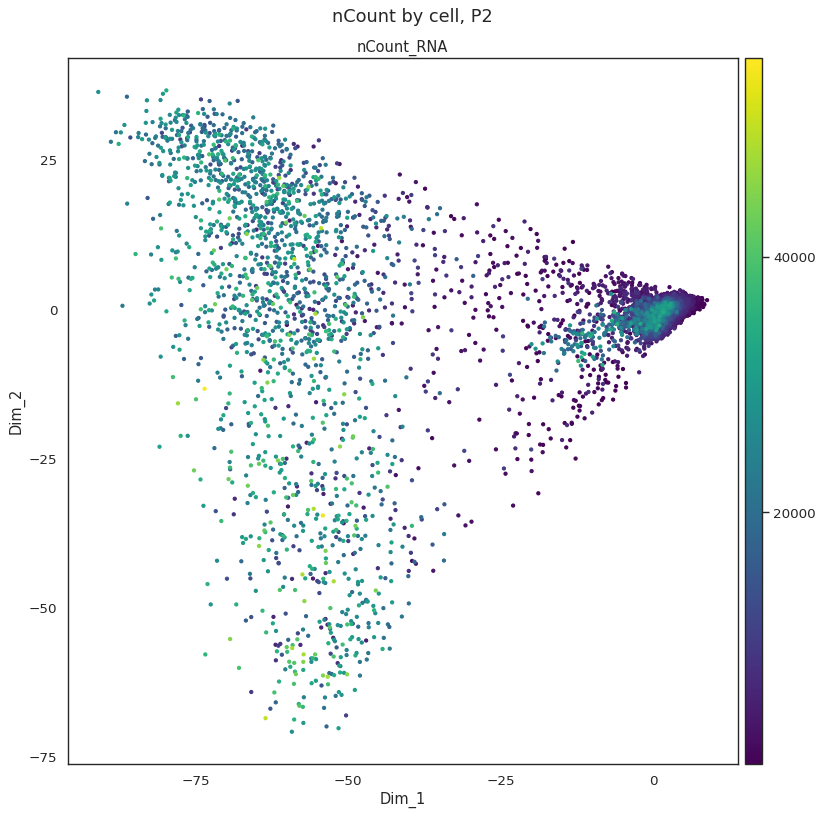

In [53]:
adata.obsm['X_dr'] = adata.obsm['X_pca']
st2.settings.set_figure_params(dpi=80,
                              style='white',
                              fig_size=[5,5],
                              rc={'image.cmap': 'viridis'})

st2.pl.dimension_reduction(adata,color=['nCount_RNA'],
                           fig_legend_ncol=2, fig_size=(10,10))
plt.suptitle(f"nCount by cell, {patient}", fontsize=16, y=1.02)
plt.savefig(f"{output_directory}/ncount_{patient}.png", dpi=300, bbox_inches='tight')

Found 1 components


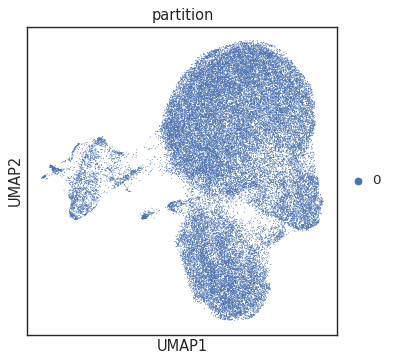

In [54]:
sc.pp.neighbors(adata,use_rep='X_pca')
sc.tl.leiden(adata)
st2.tl.find_disconnected_components(adata,groups='leiden')
sc.pl.umap(adata,color='partition')

<Axes: xlabel='partition'>

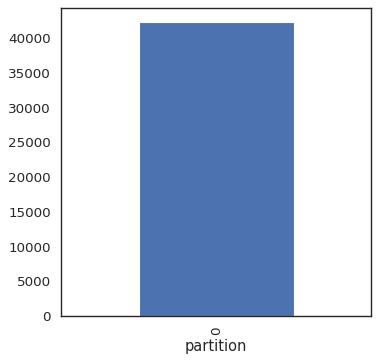

In [55]:
# Many are small clusters which are not adequate for trajectory inference and can be filtered out
# We keep components with more than 500 cells
adata.obs['partition'].value_counts().plot.bar()

Seeding initial graph for each partition...
Learning elastic principal graph for each partition...


/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/stream2/plotting/_plot.py:1110: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if ann in adata.obs_keys():
/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/stream2/plotting/_plot.py:1110: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if ann in adata.obs_keys():


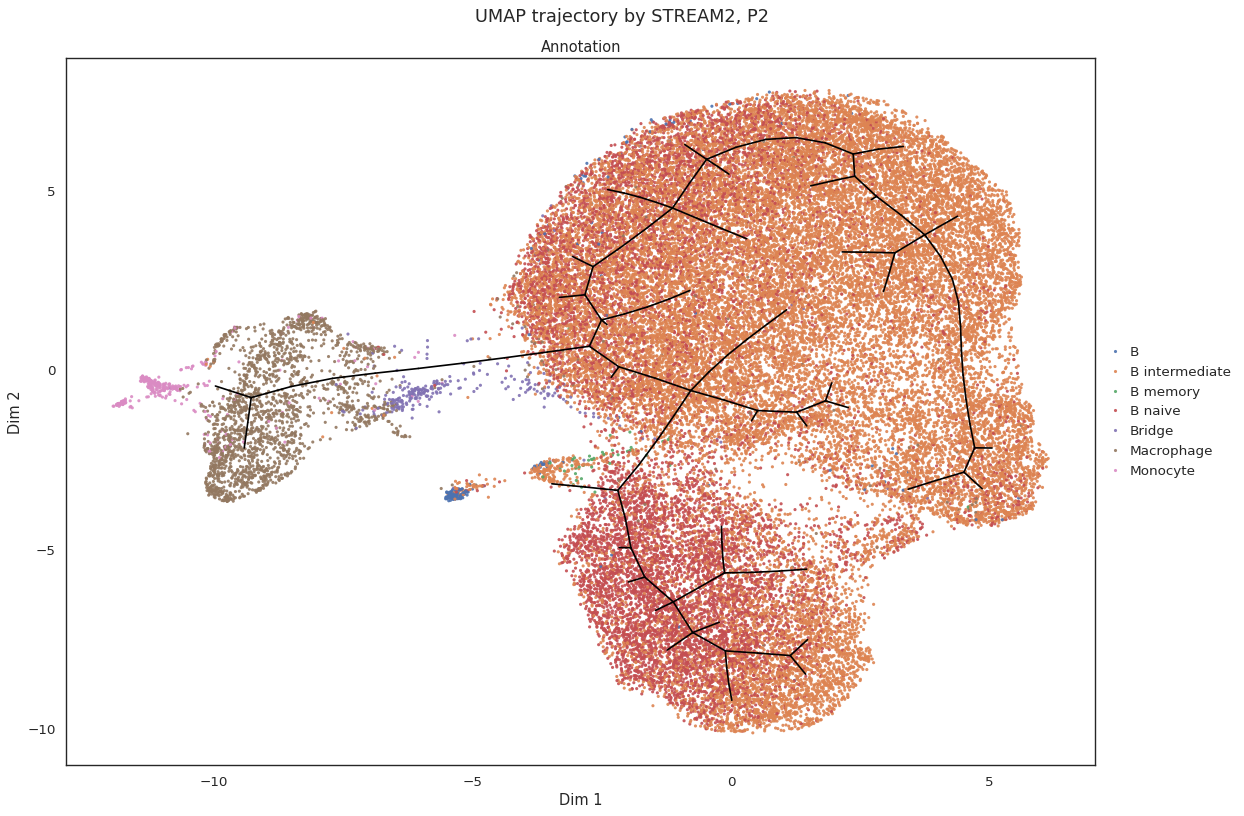

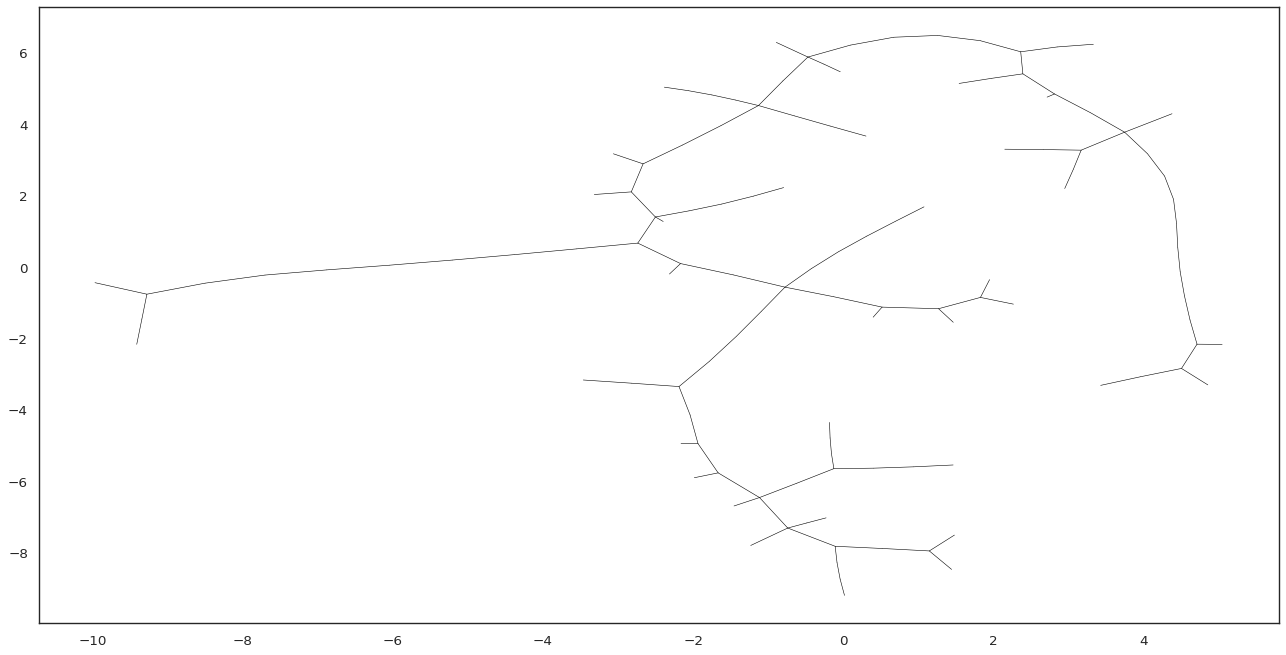

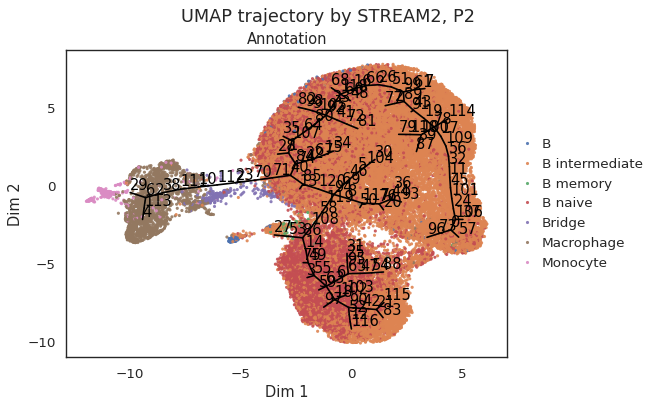

In [104]:
use_partition=['0']
dict_palette = {"D1": "#1f77b4", "D4": "#2ca02c", "D8": "#ff7f0e", "D11": "#d62728", "D14": "#9467bd"}
adata.obs["timepoint"] = adata.obs["timepoint"].astype(str)
adata.obs["timepoint"] = pd.Categorical(adata.obs["timepoint"],categories=["D1", "D4", "D8", "D11", "D14"],ordered=True) 

st2.tl.seed_graph(adata, obsm=f"{reduction}", n_clusters=120,use_partition=use_partition)
st2.tl.learn_graph(adata, obsm=f"{reduction}", n_nodes=80,epg_alpha=0.01,epg_mu=0.2,use_partition=use_partition)
st2.pl.graph(adata,key='epg',color=['Annotation'],dict_palette=dict_palette,fig_size=(15,10),save_fig=False)
plt.suptitle(f"UMAP trajectory by STREAM2, {patient}", fontsize=16, y=1.02)
plt.savefig(f"{output_directory}/graph_myel_{patient}.png", dpi=300, bbox_inches='tight')

fig, ax = plt.subplots(figsize=(15, 10))
sc.pl.umap(adata,color="timepoint",palette=dict_palette,show=False, ax=ax, size=15)
epg = adata.uns["epg"]
nodes = epg["node_pos"]
edges = epg["edge"]
for edge in edges:
    p1 = nodes[edge[0]]
    p2 = nodes[edge[1]]
    ax.plot([p1[0], p2[0]],[p1[1], p2[1]],color="black",linewidth=1.5,zorder=10)
plt.suptitle(f"UMAP trajectory by STREAM2, {patient}", fontsize=16, y=1.02)
plt.savefig(f"{output_directory}/graph_time_{patient}.png", dpi=500, bbox_inches='tight')  
plt.close()
#adata_sub.uns['epg']['leaves']

st2.tl._elpigraph._store_graph_attributes(adata,adata.obsm[f"{reduction}"],'epg')
st2.pl.graph(adata,key='epg',color=['Annotation'],show_text=True,fig_size=(8,5),save_fig=False)
plt.suptitle(f"UMAP trajectory by STREAM2, {patient}", fontsize=16, y=1.02)
plt.savefig(f"{output_directory}/graph_v2_myel_{patient}.png", dpi=300, bbox_inches='tight')
fig, ax = plt.subplots(figsize=(15, 10))
sc.pl.umap(adata,color="timepoint",palette=dict_palette,show=False, ax=ax, size=15)
epg = adata.uns["epg"]
nodes = epg["node_pos"]
edges = epg["edge"]
for edge in edges:
    p1 = nodes[edge[0]]
    p2 = nodes[edge[1]]
    ax.plot([p1[0], p2[0]],[p1[1], p2[1]],color="black",linewidth=1.5,zorder=10)
ax.scatter(nodes[:, 0],nodes[:, 1],c="black",s=1,zorder=11)
for i, (x, y) in enumerate(nodes):
    ax.annotate(str(i), xy=(x, y),xytext=(5, 5),textcoords="offset points",fontsize=10,fontweight="bold",color="black", zorder=12)
plt.suptitle(f"UMAP trajectory by STREAM2, {patient}", fontsize=16, y=1.02)
plt.savefig(f"{output_directory}/graph_time_nodes_{patient}.png", dpi=500, bbox_inches='tight')  
plt.close()

In [57]:
unique_nodes = sorted(adata.obs['epg_node_id'].dropna().unique())

# Mapping node_id in a label (N1, N2...)
epg_to_label = {node: f"N{int(node)}" for node in unique_nodes}

# Macrostate column
adata.obs["macrostate"] = np.nan
adata.obs["macrostate"] = (
    adata.obs["macrostate"]
    .astype("category")
    .cat.add_categories(sorted(epg_to_label.values()))
)

# Assign the macrostate based on the nearest node
for node, label in epg_to_label.items():
    mask = adata.obs['epg_node_id'] == node
    adata.obs.loc[mask, "macrostate"] = label

print(adata.obs['macrostate'].value_counts())

macrostate
N114    889
N30     807
N97     765
N81     755
N28     743
       ... 
N53      91
N60      79
N102     75
N70      48
N23      24
Name: count, Length: 121, dtype: int64


In [58]:
print(adata.obs.columns)
print(adata.obs["macrostate"].head())
print(adata.obs["macrostate"].unique())

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT',
       'nFeature_ADT', 'timepoint', 'doublet_finder', 'percent.mt', 'qc_pass',
       'RNA_snn_res.0.1', 'seurat_clusters', 'RNA.weight', 'ADT.weight',
       'wsnn_res.0.1', 'SingleR', 'predicted.celltype.l1',
       'predicted.celltype.l2', 'predicted.celltype.l3', 'manual_annotation',
       'final_annot', 'Annotation', 'clone_opt', 'GT_opt', 'p_opt', 'p_cnv',
       'compartment_opt', 'leiden', 'partition', 'seed_epg_node_id',
       'seed_epg_node_dist', 'seed_epg_edge_id', 'seed_epg_edge_loc',
       'seed_epg_edge_dist', 'epg_node_id', 'epg_node_dist', 'epg_edge_id',
       'epg_edge_loc', 'epg_edge_dist', 'macrostate'],
      dtype='object')
D1_AAACCCAAGTCCCGAC-1    N116
D1_AAACCCACATAGCACT-1     N92
D1_AAACCCACATGGCCCA-1    N114
D1_AAACCCAGTCTTTCTA-1     N56
D1_AAACCCAGTTCTAAGC-1      N5
Name: macrostate, dtype: category
Categories (121, object): ['N0', 'N1', 'N10', 'N100', ..., 'N96', 'N97', 'N98', 'N99']
['N116

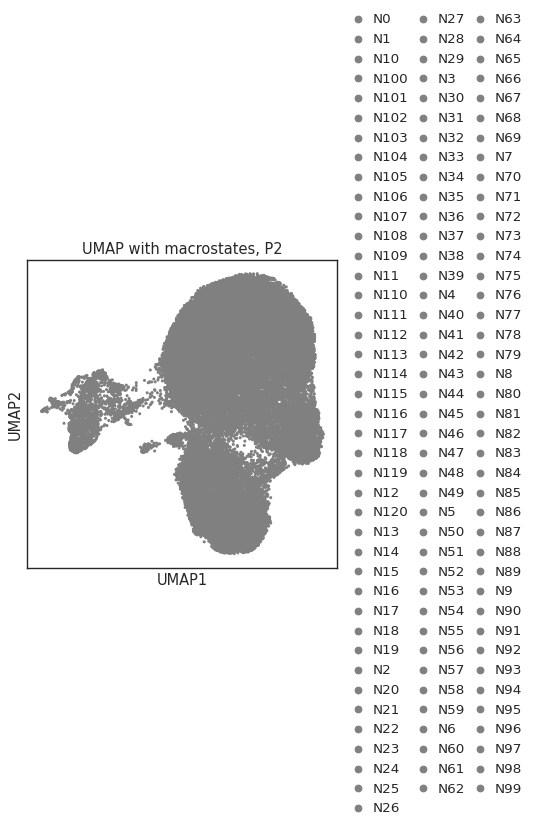

In [59]:
ax = sc.pl.umap(adata,color="macrostate",title=f"UMAP with macrostates, {patient}",size=30,show=False)
sc.pl.umap(adata,color="macrostate",title=f"UMAP with macrostates, {patient}",size=30,show=False)
#ax.figure.savefig(f"{output_directory}/umap_macrostages_{patient}.png", dpi=150, bbox_inches="tight")

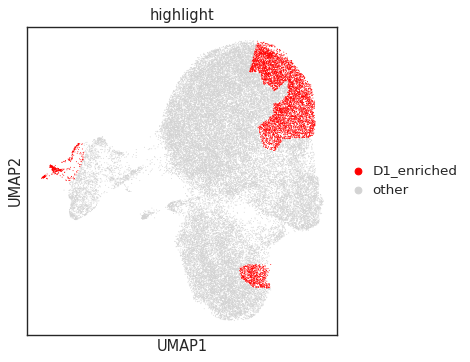

             prop_D1  n_cells  B  B intermediate  B naive  Bridge  Macrophage  \
macrostate                                                                      
N29         0.678947      380  0               4        0       1         115   
N109        0.496386      415  0             400       15       0           0   
N7          0.472318      578  0             559       19       0           0   
N17         0.450704      284  0             282        2       0           0   
N114        0.446569      889  0             878       11       0           0   
N99         0.410256      195  0             173       22       0           0   
N61         0.401055      379  0             354       25       0           0   
N89         0.391813      171  0             156       15       0           0   
N78         0.381720      186  0             181        4       0           1   
N39         0.369159      214  0             201       13       0           0   
N87         0.363025      59

In [83]:
ct = pd.crosstab(adata.obs["macrostate"], adata.obs["timepoint"])

# days proportion (D1)
prop_D1 = ct["D1"] / ct.sum(axis=1)
# Macrostates D1-enriched (>30%) selection
selected_macrostates = prop_D1[prop_D1 > 0.30].index
# Column for UMAP
adata.obs["highlight"] = adata.obs["macrostate"].isin(selected_macrostates)
adata.obs["highlight"] = adata.obs["highlight"].map({True: "D1_enriched", False: "other"})
sc.pl.umap(adata, color="highlight", palette={"D1_enriched": "red", "other": "lightgrey"})
# Macrostates subset
subset = adata.obs.loc[
    adata.obs["macrostate"].isin(selected_macrostates), ["macrostate", "Annotation"]
].copy()
subset["macrostate"] = subset["macrostate"].astype(str)
subset["Annotation"] = subset["Annotation"].astype(str)
# Count cells per macrostates and per celltype 
annotation_counts = subset.groupby(["macrostate", "Annotation"]).size().unstack(fill_value=0)

# DataFrame
prop_D1_selected = prop_D1.loc[annotation_counts.index]
total_counts = subset["macrostate"].value_counts().reindex(annotation_counts.index)
result = pd.DataFrame({
    "prop_D1": prop_D1_selected,
    "n_cells": total_counts})
result = result.join(annotation_counts, how="left")
print(result)

Choose the initial macrostates 
Nodes 115 and 114, and only cells from D1 and annotated as B intermediate

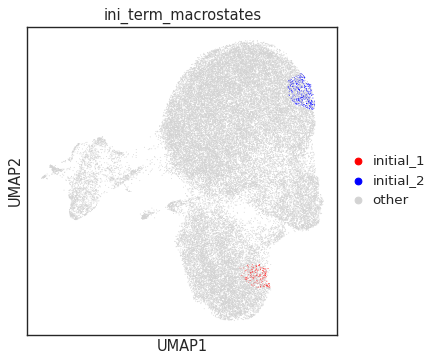

ini_term_macrostates
other        41625
initial_2      395
initial_1      196
Name: count, dtype: int64

In [126]:
adata.obs["ini_term_macrostates"] = "other"
# Initial_1
mask_1 = ((adata.obs["macrostate"] == "N115") & (adata.obs["timepoint"] == "D1") & (adata.obs["Annotation"] == "B intermediate"))
# Initial_2
mask_2 = ((adata.obs["macrostate"] == "N114") & (adata.obs["timepoint"] == "D1") & (adata.obs["Annotation"] == "B intermediate"))

adata.obs.loc[mask_1, "ini_term_macrostates"] = "initial_1"
adata.obs.loc[mask_2, "ini_term_macrostates"] = "initial_2"

sc.pl.umap( adata, color="ini_term_macrostates", palette={"initial_1": "red", "initial_2": "blue", "other": "lightgrey"})

adata.obs["ini_term_macrostates"].value_counts()

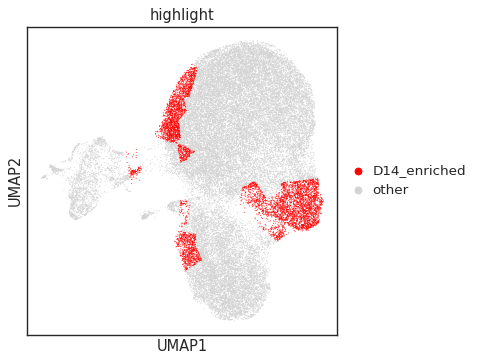

            prop_D14  n_cells   B  B intermediate  B memory  B naive  Bridge  \
macrostate                                                                     
N0          0.576389      144   0             126         0       18       0   
N106        0.562814      199   0             185         0       13       0   
N112        0.438596      114   0               1         0        1     104   
N20         0.498660      373   1             316         0       54       0   
N24         0.533333      390   0             372         0       18       0   
N28         0.481830      743   0             435         0      299       0   
N3          0.514218      422   0              70         0      352       0   
N35         0.508501      647   8             354         0      281       2   
N37         0.630380      395   0             369         0       25       0   
N40         0.437722      281   0             190         1       88       0   
N53         0.461538       91   0       

In [118]:
# days proportion (D14)
prop_D14 = ct["D14"] / ct.sum(axis=1)
# Macrostates D1-enriched (>40%) selection
selected_macrostates = prop_D14[prop_D14 > 0.40].index
# Column for UMAP
adata.obs["highlight"] = adata.obs["macrostate"].isin(selected_macrostates)
adata.obs["highlight"] = adata.obs["highlight"].map({True: "D14_enriched", False: "other"})
sc.pl.umap(adata, color="highlight", palette={"D14_enriched": "red", "other": "lightgrey"})
# Macrostates subset
subset = adata.obs.loc[
    adata.obs["macrostate"].isin(selected_macrostates), ["macrostate", "Annotation"]
].copy()
subset["macrostate"] = subset["macrostate"].astype(str)
subset["Annotation"] = subset["Annotation"].astype(str)
# Count cells per macrostates and per celltype 
annotation_counts = subset.groupby(["macrostate", "Annotation"]).size().unstack(fill_value=0)

# DataFrame
prop_D14_selected = prop_D14.loc[annotation_counts.index]
total_counts = subset["macrostate"].value_counts().reindex(annotation_counts.index)
result = pd.DataFrame({
    "prop_D14": prop_D14_selected,
    "n_cells": total_counts})
result = result.join(annotation_counts, how="left")
print(result)

In [ ]:
Choose the initial macrostates 
Nodes 112,3 and 57, and only cells from D14 and annotated as B intermediate

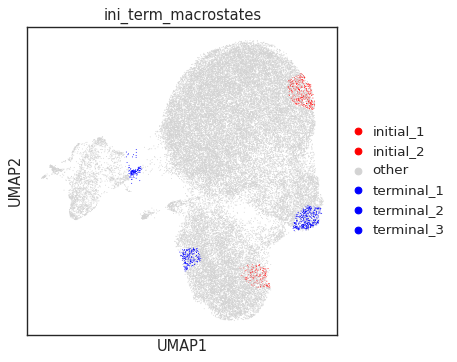

ini_term_macrostates
other         40966
initial_2       395
terminal_3      358
initial_1       196
terminal_2      187
terminal_1      114
Name: count, dtype: int64

In [127]:
adata.obs["ini_term_macrostates"] = adata.obs["ini_term_macrostates"].cat.add_categories(
    ["terminal_1", "terminal_2", "terminal_3"])
# Terminal_1
mask_1 = ((adata.obs["macrostate"] == "N112"))
# Terminal_2
mask_2 = ((adata.obs["macrostate"] == "N3") & (adata.obs["timepoint"] == "D14") & (adata.obs["Annotation"] == "B naive"))
# Terminal_3
mask_3 = ((adata.obs["macrostate"] == "N57") & (adata.obs["timepoint"] == "D14") & (adata.obs["Annotation"] == "B intermediate"))

adata.obs.loc[mask_1, "ini_term_macrostates"] = "terminal_1"
adata.obs.loc[mask_2, "ini_term_macrostates"] = "terminal_2"
adata.obs.loc[mask_3, "ini_term_macrostates"] = "terminal_3"

sc.pl.umap( adata, color="ini_term_macrostates", palette={"initial_1": "red", "initial_2": "red","terminal_1": "blue", 
                                                         "terminal_2": "blue","terminal_3":"blue", "other": "lightgrey" })

adata.obs["ini_term_macrostates"].value_counts()


In [130]:
fig, ax = plt.subplots(figsize=(15, 10))
sc.pl.umap(adata, color="ini_term_macrostates", ax=ax, show=False, size=20, palette={"initial_1": "red", "initial_2": "red","terminal_1": "blue", 
                                                         "terminal_2": "blue","terminal_3":"blue", "other": "lightgrey" })
plt.suptitle(f"UMAP initial and terminal macrostates, {patient}", fontsize=16, y=1.02)
plt.savefig(f"{output_directory}/graph_macrostates_{patient}.png", dpi=500, bbox_inches='tight')  
plt.close()

In [ ]:
ax = sc.pl.pca(adata,color="macrostate",title=f"PCA with macrostates, {patient}",size=30,show=False)
ax.figure.savefig(f"{output_directory}/pca_macrostages_{patient}.png", dpi=150, bbox_inches="tight")

In [ ]:
ax = sc.pl.tsne(adata,color="macrostate",title=f"T-sne with macrostates, {patient}",size=30,show=False)
ax.figure.savefig(f"{output_directory}/tsne_macrostages_{patient}.png", dpi=150, bbox_inches="tight")